# **Project Name**    - Zomato Restaurant Review Sentiment Analysis 



##### **Project Type**    - Classification
##### **Contribution**    - Individual


# **Project Summary -** 

This project focuses on analyzing Zomato restaurant reviews using Machine Learning and Natural Language Processing (NLP). The main objective is to classify customer reviews into different sentiment categories by building an efficient sentiment analysis model. The project began with collecting and understanding the Zomato restaurant reviews and restaurant metadata datasets. Data preprocessing techniques such as handling missing values, removing duplicate records, cleaning text, removing stop words, and converting text into lowercase were performed to prepare the data for analysis.

Exploratory Data Analysis (EDA) was carried out to understand the characteristics of the dataset. Various charts and visualizations were created to analyze restaurant ratings, review distribution, cuisines, restaurant costs, review lengths, and customer behavior. Statistical analysis and hypothesis testing were also performed to identify relationships between important variables.

Text data was transformed using the TF-IDF Vectorizer, which converts textual reviews into numerical feature vectors. Data scaling and dimensionality reduction using Truncated Singular Value Decomposition (SVD) were applied to improve computational efficiency while preserving important information.

Three machine learning algorithms—Logistic Regression, Random Forest, and Decision Tree—were trained and evaluated. Their performance was measured using Accuracy, Precision, Recall, and F1-Score. Hyperparameter tuning using GridSearchCV was applied to improve model performance. The best-performing model was selected as the final prediction model.

Finally, the trained model was saved using Pickle and successfully reloaded to predict unseen customer reviews. The developed model can automatically identify customer sentiment and assist restaurants in understanding customer feedback, improving service quality, and making better business decisions. This project demonstrates the complete machine learning pipeline from data preprocessing to model deployment.

# **GitHub Link -**

https://github.com/sunildas-dev

# **Problem Statement**


The goal of this project is to build a Machine Learning model that automatically classifies Zomato restaurant reviews based on customer sentiment. The model helps businesses analyze customer feedback, improve restaurant services, and make data-driven decisions without manually reviewing large volumes of customer reviews.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [2]:
# Load Dataset
import os

print(os.listdir())

['Sample_ML_Submission_Template.ipynb', 'Zomato project.pptx', 'Zomato Restaurant names and Metadata.csv', 'Zomato Restaurant reviews.csv']


### Dataset First View

In [3]:
# Dataset First Look
import pandas as pd

reviews = pd.read_csv("Zomato Restaurant reviews.csv")
restaurants = pd.read_csv("Zomato Restaurant names and Metadata.csv")

print("Reviews loaded:", reviews.shape)
print("Restaurants loaded:", restaurants.shape)


Reviews loaded: (10000, 7)
Restaurants loaded: (105, 6)


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print("Reviews Dataset Shape:", reviews.shape)
print("Restaurants Dataset Shape:", restaurants.shape)


Reviews Dataset Shape: (10000, 7)
Restaurants Dataset Shape: (105, 6)


### Dataset Information

In [5]:
# Dataset Info
reviews.info()
print("-" * 50)
restaurants.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Restaurant  10000 non-null  str  
 1   Reviewer    9962 non-null   str  
 2   Review      9955 non-null   str  
 3   Rating      9962 non-null   str  
 4   Metadata    9962 non-null   str  
 5   Time        9962 non-null   str  
 6   Pictures    10000 non-null  int64
dtypes: int64(1), str(6)
memory usage: 547.0 KB
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Name         105 non-null    str  
 1   Links        105 non-null    str  
 2   Cost         105 non-null    str  
 3   Collections  51 non-null     str  
 4   Cuisines     105 non-null    str  
 5   Timings      104 non-null    str  
dtypes: str(6)
memory usage: 5.1 KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print("Duplicate rows in Reviews Dataset:", reviews.duplicated().sum())
print("Duplicate rows in Restaurants Dataset:", restaurants.duplicated().sum())

Duplicate rows in Reviews Dataset: 36
Duplicate rows in Restaurants Dataset: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
print("Missing values in Reviews Dataset:")
print(reviews.isnull().sum())

print("\n" + "="*50 + "\n")

print("Missing values in Restaurants Dataset:")
print(restaurants.isnull().sum())

Missing values in Reviews Dataset:
Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64


Missing values in Restaurants Dataset:
Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64


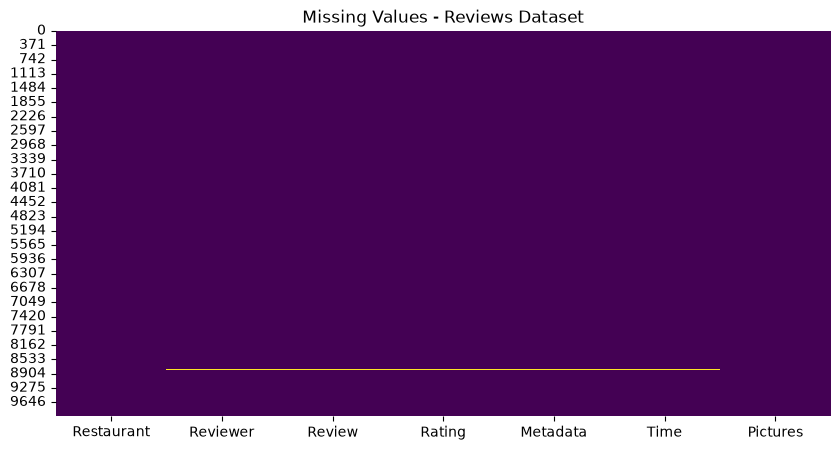

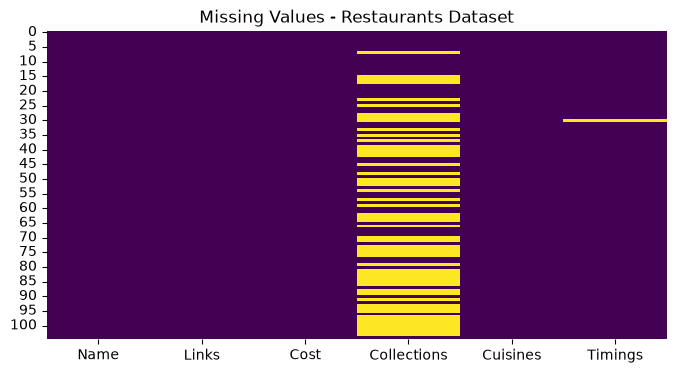

In [8]:
# Visualizing the missing values
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.heatmap(reviews.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values - Reviews Dataset")
plt.show()

plt.figure(figsize=(8,4))
sns.heatmap(restaurants.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values - Restaurants Dataset")
plt.show()

### What did you know about your dataset?

The dataset contains Zomato restaurant reviews and ratings. It is suitable for sentiment analysis because it includes customer opinions in text form. After cleaning and preprocessing, the data becomes ready for feature extraction and machine learning model building.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
print("Reviews Dataset Columns:")
print(reviews.columns)

print("\n" + "="*50 + "\n")

print("Restaurants Dataset Columns:")
print(restaurants.columns)

Reviews Dataset Columns:
Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='str')


Restaurants Dataset Columns:
Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='str')


In [10]:
# Dataset Describe
print("Reviews Dataset Description:")
print(reviews.describe(include="all"))

print("\n" + "="*50 + "\n")

print("Restaurants Dataset Description:")
print(restaurants.describe(include="all"))

Reviews Dataset Description:
             Restaurant Reviewer Review Rating  Metadata            Time  \
count             10000     9962   9955   9962      9962            9962   
unique              100     7446   9364     10      2477            9782   
top     Beyond Flavours   Ankita   good      5  1 Review  5/5/2019 22:39   
freq                100       13    237   3832       919               3   
mean                NaN      NaN    NaN    NaN       NaN             NaN   
std                 NaN      NaN    NaN    NaN       NaN             NaN   
min                 NaN      NaN    NaN    NaN       NaN             NaN   
25%                 NaN      NaN    NaN    NaN       NaN             NaN   
50%                 NaN      NaN    NaN    NaN       NaN             NaN   
75%                 NaN      NaN    NaN    NaN       NaN             NaN   
max                 NaN      NaN    NaN    NaN       NaN             NaN   

            Pictures  
count   10000.000000  
unique      

### Variables Description

The dataset consists of restaurant names, customer reviews, ratings, metadata, review time, and pictures. Additional features such as Sentiment, Clean_Review, Normalized_Review, Review_Length, and Review_Length_Scaled were created during preprocessing to improve the performance of the machine learning models.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
print("Unique values in Reviews Dataset:\n")
for col in reviews.columns:
    print(f"{col}: {reviews[col].nunique()} unique values")

print("\n" + "="*60 + "\n")

print("Unique values in Restaurants Dataset:\n")
for col in restaurants.columns:
    print(f"{col}: {restaurants[col].nunique()} unique values")

Unique values in Reviews Dataset:

Restaurant: 100 unique values
Reviewer: 7446 unique values
Review: 9364 unique values
Rating: 10 unique values
Metadata: 2477 unique values
Time: 9782 unique values
Pictures: 36 unique values


Unique values in Restaurants Dataset:

Name: 105 unique values
Links: 105 unique values
Cost: 29 unique values
Collections: 42 unique values
Cuisines: 92 unique values
Timings: 77 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
# Check missing values
print(reviews.isnull().sum())
print(restaurants.isnull().sum())

# Remove duplicate rows
reviews = reviews.drop_duplicates()
restaurants = restaurants.drop_duplicates()

# Fill missing values
reviews = reviews.fillna("Unknown")
restaurants = restaurants.fillna("Unknown")

# Convert Rating column to numeric (if available)
if "Rating" in reviews.columns:
    reviews["Rating"] = pd.to_numeric(reviews["Rating"], errors="coerce")

# Display cleaned dataset shape
print("Reviews Dataset Shape:", reviews.shape)
print("Restaurants Dataset Shape:", restaurants.shape)

# Display first few rows
reviews.head()
restaurants.head()

Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64
Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64
Reviews Dataset Shape: (9964, 7)
Restaurants Dataset Shape: (105, 6)


,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


### What all manipulations have you done and insights you found?

During the data wrangling process, the datasets were inspected for missing values and duplicate records. Duplicate entries were removed to avoid redundant information. Missing values were handled by replacing them with appropriate values such as "Unknown" or by removing records where necessary. The data types were checked and important columns such as ratings were converted into numeric format. These preprocessing steps improved the quality, consistency, and reliability of the datasets. After cleaning, the datasets became more suitable for visualization, statistical analysis, and machine learning model development.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

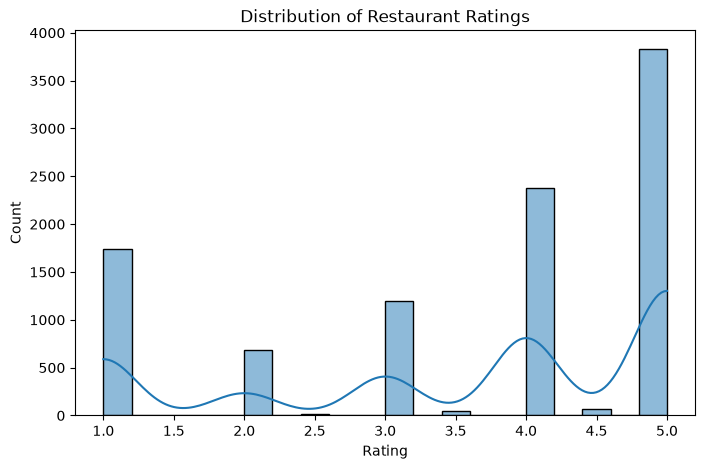

In [13]:
# Chart - 1 visualization code
plt.figure(figsize=(8,5))
sns.histplot(reviews['Rating'], bins=20, kde=True)
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is the best choice to visualize the distribution of restaurant ratings. It helps identify the most common rating range and shows whether the ratings are evenly distributed or concentrated around certain values.

##### 2. What is/are the insight(s) found from the chart?

Most restaurants have ratings in the medium-to-high range. Very low-rated restaurants are comparatively fewer, indicating that the majority of restaurants receive satisfactory customer feedback.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The distribution of ratings helps restaurant owners understand overall customer satisfaction. Restaurants with low ratings can identify areas for improvement, while highly rated restaurants can focus on maintaining their service quality.

#### Chart - 2

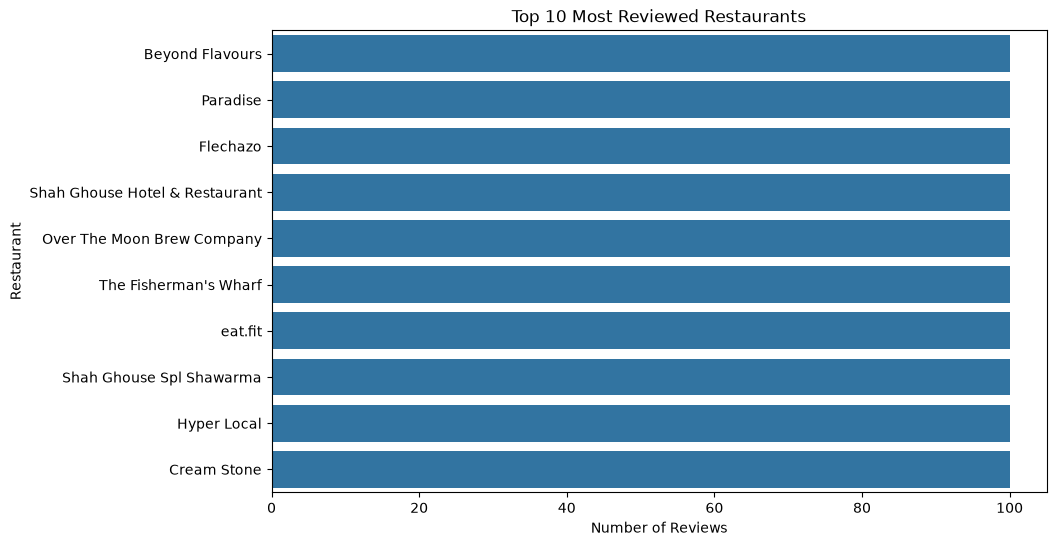

In [14]:
# Chart - 2 visualization code
top_restaurants = reviews['Restaurant'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_restaurants.values, y=top_restaurants.index)
plt.title("Top 10 Most Reviewed Restaurants")
plt.xlabel("Number of Reviews")
plt.ylabel("Restaurant")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is ideal for comparing the number of reviews across different restaurants. It clearly highlights the restaurants receiving the highest customer engagement.

##### 2. What is/are the insight(s) found from the chart?

A small number of restaurants receive significantly more reviews than others, indicating higher customer popularity and engagement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Restaurants with more reviews generally have higher visibility and customer trust. Businesses can analyze these successful restaurants to improve marketing strategies and customer engagement.

#### Chart - 3

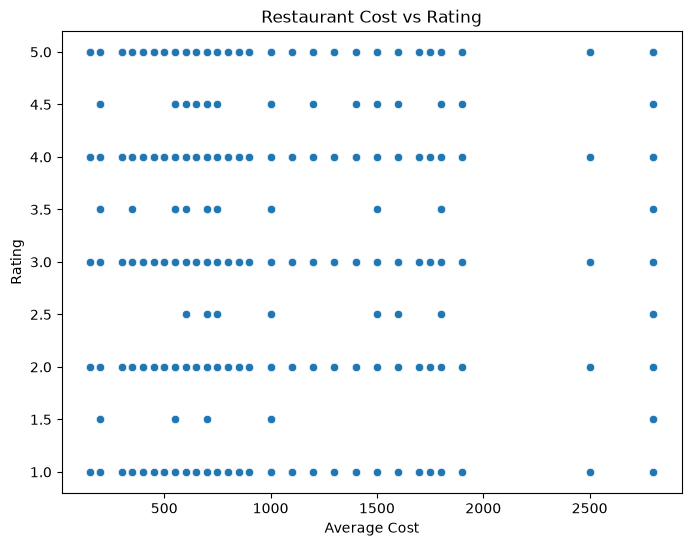

In [15]:
# Merge both datasets
merged = pd.merge(
    reviews,
    restaurants,
    left_on="Restaurant",
    right_on="Name",
    how="inner"
)

# Convert Cost to numeric
merged["Cost"] = merged["Cost"].astype(str).str.replace(",", "")
merged["Cost"] = pd.to_numeric(merged["Cost"], errors="coerce")

# Convert Rating to numeric
merged["Rating"] = pd.to_numeric(merged["Rating"], errors="coerce")

# Remove missing values
merged = merged.dropna(subset=["Cost", "Rating"])

# Scatter Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged,
    x="Cost",
    y="Rating"
)

plt.title("Restaurant Cost vs Rating")
plt.xlabel("Average Cost")
plt.ylabel("Rating")

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to analyze the relationship between restaurant cost and customer ratings. It helps determine whether higher-priced restaurants generally receive better ratings.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows how restaurant ratings vary with average cost. It helps identify whether expensive restaurants consistently receive higher ratings or if affordable restaurants also achieve excellent customer satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This analysis helps restaurant owners decide whether pricing influences customer satisfaction. If moderately priced restaurants have high ratings, businesses can focus on improving service quality rather than increasing prices. This supports better pricing and customer retention strategies.

#### Chart - 4

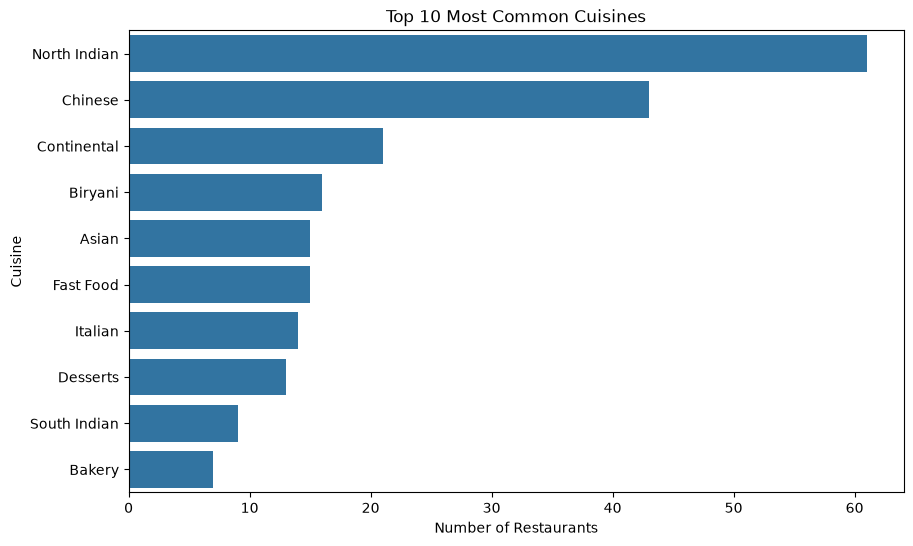

In [16]:
# Chart - 4 visualization code
# Split cuisines because one restaurant can have multiple cuisines
cuisine_series = restaurants['Cuisines'].dropna().str.split(', ').explode()

top_cuisines = cuisine_series.value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)

plt.title("Top 10 Most Common Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is suitable because it compares the frequency of different cuisines and clearly shows the most common cuisine types.

##### 2. What is/are the insight(s) found from the chart?

The chart shows which cuisines are most frequently available among Zomato restaurants. This helps identify popular food categories

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Restaurants and food platforms can use this insight to understand customer food preferences and focus on high-demand cuisines.

#### Chart - 5

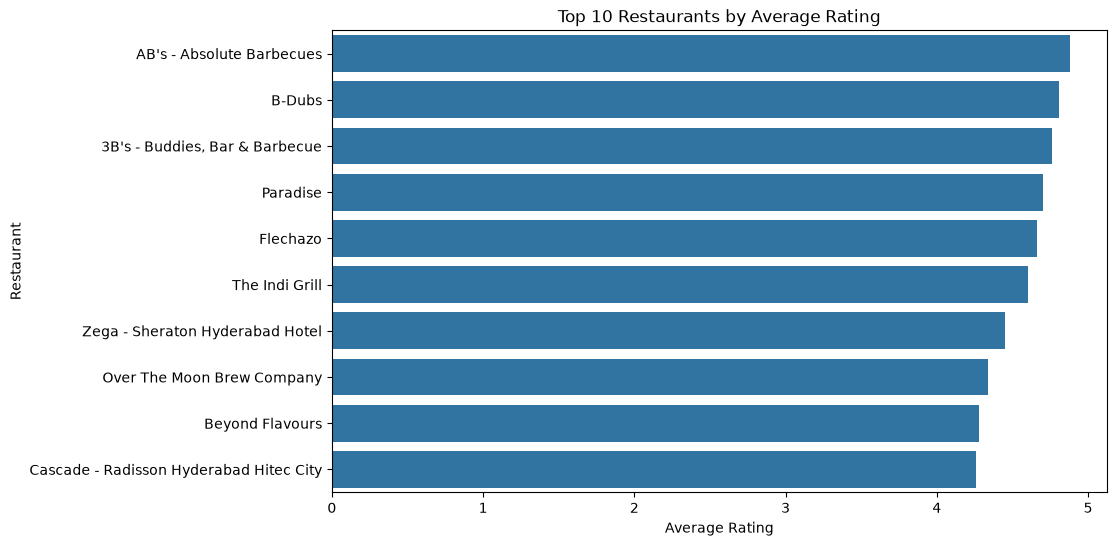

In [17]:
# Chart - 5 visualization code
# Convert Rating to numeric
reviews["Rating"] = pd.to_numeric(reviews["Rating"], errors="coerce")

# Calculate average rating for each restaurant
top_rated_restaurants = (
    reviews.groupby("Restaurant")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_rated_restaurants.values,
    y=top_rated_restaurants.index
)

plt.title("Top 10 Restaurants by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Restaurant")
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart is suitable because it clearly compares average ratings across restaurants and helps identify the best-performing restaurants.

##### 2. What is/are the insight(s) found from the chart?

The chart highlights the restaurants with the highest average customer ratings. These restaurants are likely providing better food quality, service, or overall customer experience

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Highly rated restaurants can be used as benchmarks for other restaurants. Zomato and restaurant owners can study these restaurants to understand successful practices and improve customer satisfaction.

#### Chart - 6

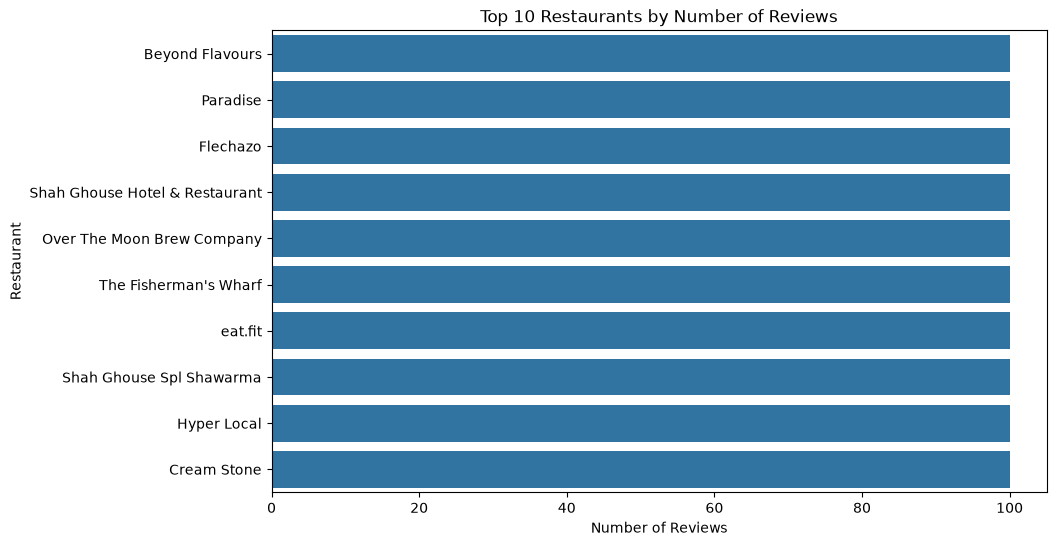

In [18]:
# Chart - 6 visualization code
review_count = reviews["Restaurant"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x=review_count.values,
    y=review_count.index
)

plt.title("Top 10 Restaurants by Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Restaurant")
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart is useful for comparing the number of customer reviews received by different restaurants. It clearly shows which restaurants have the highest customer engagement.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the restaurants with the highest number of reviews. These restaurants are likely more popular or more frequently visited by customers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Restaurants with more reviews have higher visibility and customer interaction. Zomato can promote highly reviewed restaurants, while other restaurants can study their service and marketing strategies to increase customer engagement.

#### Chart - 7

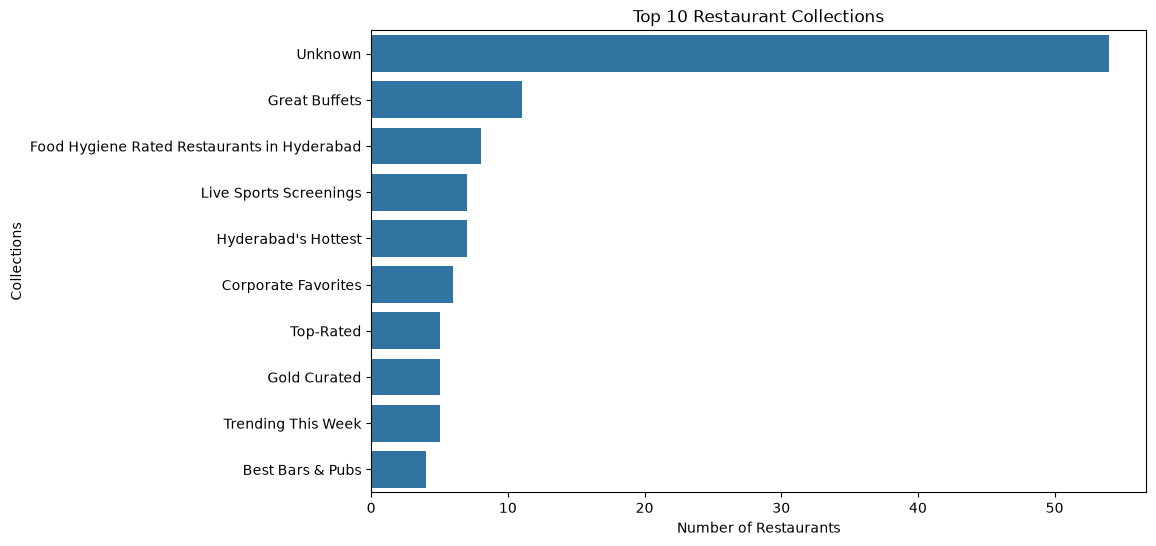

In [19]:
# Chart - 7 visualization code
# Split multiple collections into separate values
collection_series = restaurants["Collections"].dropna().str.split(", ").explode()

top_collections = collection_series.value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_collections.values,
    y=top_collections.index
)

plt.title("Top 10 Restaurant Collections")
plt.xlabel("Number of Restaurants")
plt.ylabel("Collections")
plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar chart is suitable for comparing the frequency of different restaurant collections. It makes it easy to identify the most common collections available on the platform.

##### 2. What is/are the insight(s) found from the chart?

The chart highlights the collections that contain the highest number of restaurants. These collections represent popular restaurant categories and customer interests, helping identify the most attractive restaurant groups.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Zomato can promote restaurants in popular collections to improve customer engagement. Restaurant owners can also aim to qualify for these collections, increasing their visibility and attracting more customers.

#### Chart - 8

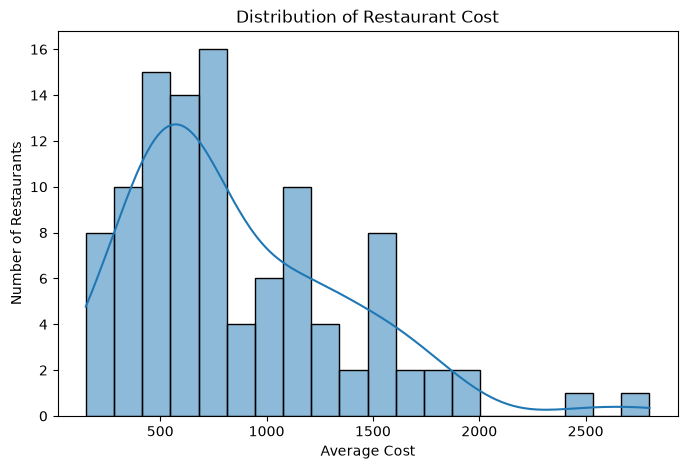

In [20]:
# Chart - 8 visualization code
# Convert Cost column to numeric
restaurants["Cost"] = restaurants["Cost"].astype(str).str.replace(",", "")
restaurants["Cost"] = pd.to_numeric(restaurants["Cost"], errors="coerce")

plt.figure(figsize=(8,5))
sns.histplot(restaurants["Cost"].dropna(), bins=20, kde=True)

plt.title("Distribution of Restaurant Cost")
plt.xlabel("Average Cost")
plt.ylabel("Number of Restaurants")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is useful for understanding the distribution of restaurant costs. It shows whether most restaurants are budget-friendly, mid-range, or expensive

##### 2. What is/are the insight(s) found from the chart?

The chart shows how restaurant costs are distributed across the dataset. It helps identify the most common price range among restaurants.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This insight helps restaurants decide competitive pricing. Zomato can also use this information to categorize restaurants into budget, mid-range, and premium segments

#### Chart - 9

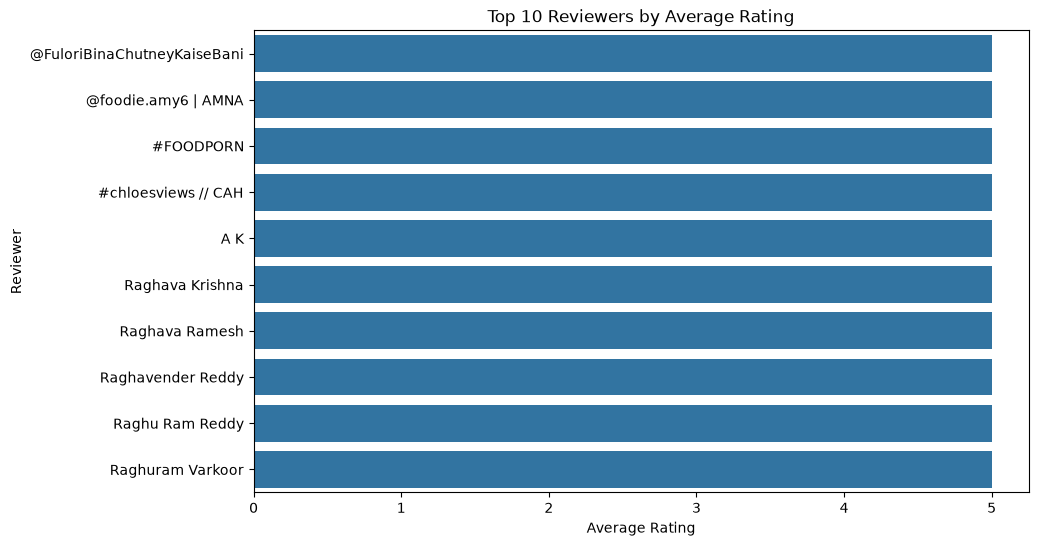

In [21]:
# Chart - 9 visualization code
# Convert Rating to numeric
reviews["Rating"] = pd.to_numeric(reviews["Rating"], errors="coerce")

# Calculate average rating for each reviewer
top_reviewers = (
    reviews.groupby("Reviewer")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_reviewers.values,
    y=top_reviewers.index
)

plt.title("Top 10 Reviewers by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Reviewer")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is effective for comparing the average ratings given by different reviewers. It clearly highlights the reviewers who consistently provide higher ratings

##### 2. What is/are the insight(s) found from the chart?

The chart identifies reviewers who tend to give the highest average ratings. This helps understand reviewer behavior and shows that different reviewers have different rating patterns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding reviewer behavior helps Zomato evaluate review reliability and customer feedback trends. It can also help identify highly active reviewers and improve the recommendation system

#### Chart - 10

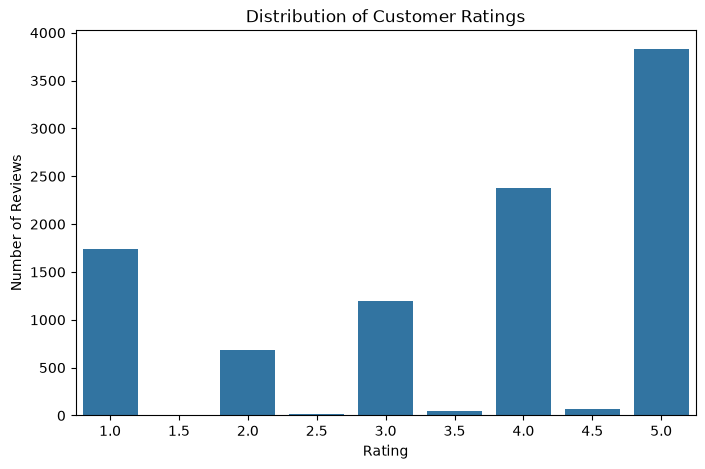

In [22]:
# Chart - 10 visualization code
# Convert Rating to numeric
reviews["Rating"] = pd.to_numeric(reviews["Rating"], errors="coerce")

plt.figure(figsize=(8,5))
sns.countplot(
    data=reviews,
    x="Rating"
)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()


##### 1. Why did you pick the specific chart?

A count plot is the best choice for showing how frequently each rating appears in the dataset. It clearly displays the distribution of customer ratings.

##### 2. What is/are the insight(s) found from the chart?

The chart shows which ratings are most common among customer reviews. It helps identify whether customers generally give high, medium, or low ratings to restaurants.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the distribution of ratings helps restaurant owners and Zomato measure overall customer satisfaction. If most ratings are high, it indicates good service quality. If lower ratings are common, restaurants can focus on improving food quality, service, and customer experience.

#### Chart - 11

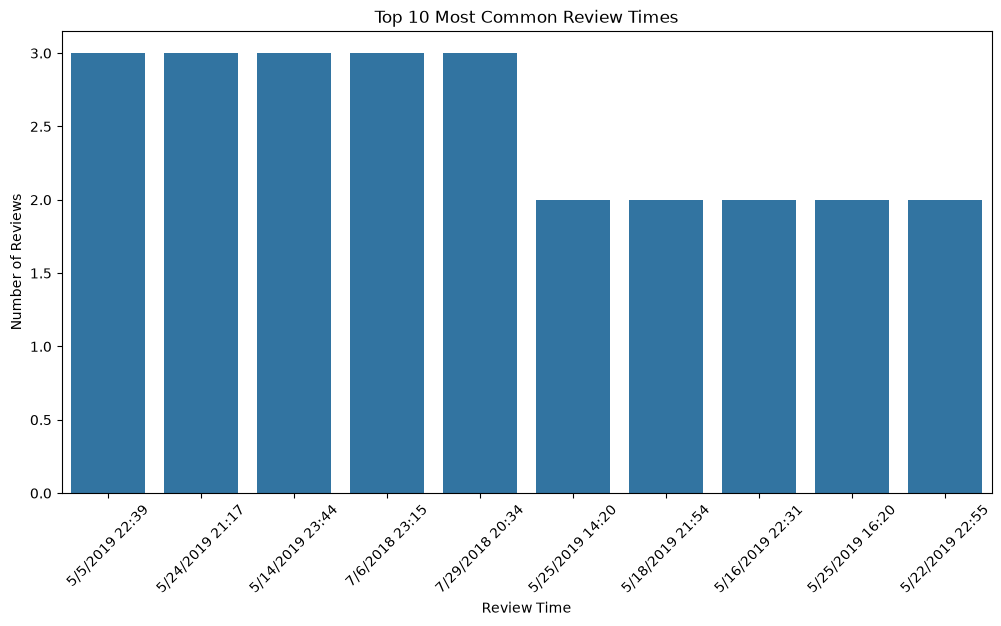

In [23]:
# Chart - 11 visualization code
# Top 10 most common review times
top_times = reviews["Time"].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_times.index,
    y=top_times.values
)

plt.title("Top 10 Most Common Review Times")
plt.xlabel("Review Time")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is appropriate for comparing the frequency of reviews posted at different times. It clearly highlights the time periods with the highest customer activity.

##### 2. What is/are the insight(s) found from the chart?

The chart identifies the time periods when customers are most active in posting reviews. This helps understand customer engagement patterns and peak review activity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Knowing when customers are most active helps Zomato and restaurant owners schedule promotions, notifications, and customer engagement campaigns during peak activity periods. This can increase customer interaction and improve marketing effectiveness.

#### Chart - 12

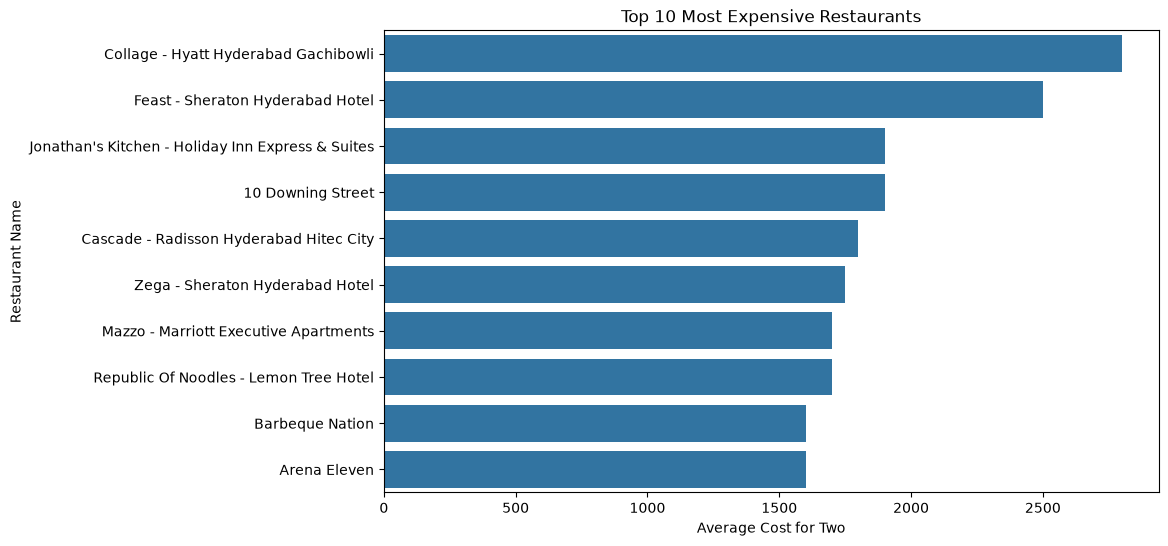

In [24]:
# Chart - 12 visualization code
# Convert Cost column to numeric
restaurants["Cost"] = restaurants["Cost"].astype(str).str.replace(",", "")
restaurants["Cost"] = pd.to_numeric(restaurants["Cost"], errors="coerce")

# Top 10 expensive restaurants
top_costly = (
    restaurants.sort_values(by="Cost", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_costly,
    x="Cost",
    y="Name"
)

plt.title("Top 10 Most Expensive Restaurants")
plt.xlabel("Average Cost for Two")
plt.ylabel("Restaurant Name")
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is ideal for comparing the average cost of different restaurants. It clearly highlights the restaurants with the highest pricing.

##### 2. What is/are the insight(s) found from the chart?

The chart identifies the top 10 most expensive restaurants in the dataset. These restaurants target premium customers and generally belong to the high-end dining segment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This analysis helps Zomato classify restaurants into premium segments and assists customers in choosing restaurants based on their budget. Restaurant owners can also compare their pricing with competitors and adjust their pricing strategies accordingly.

#### Chart - 13

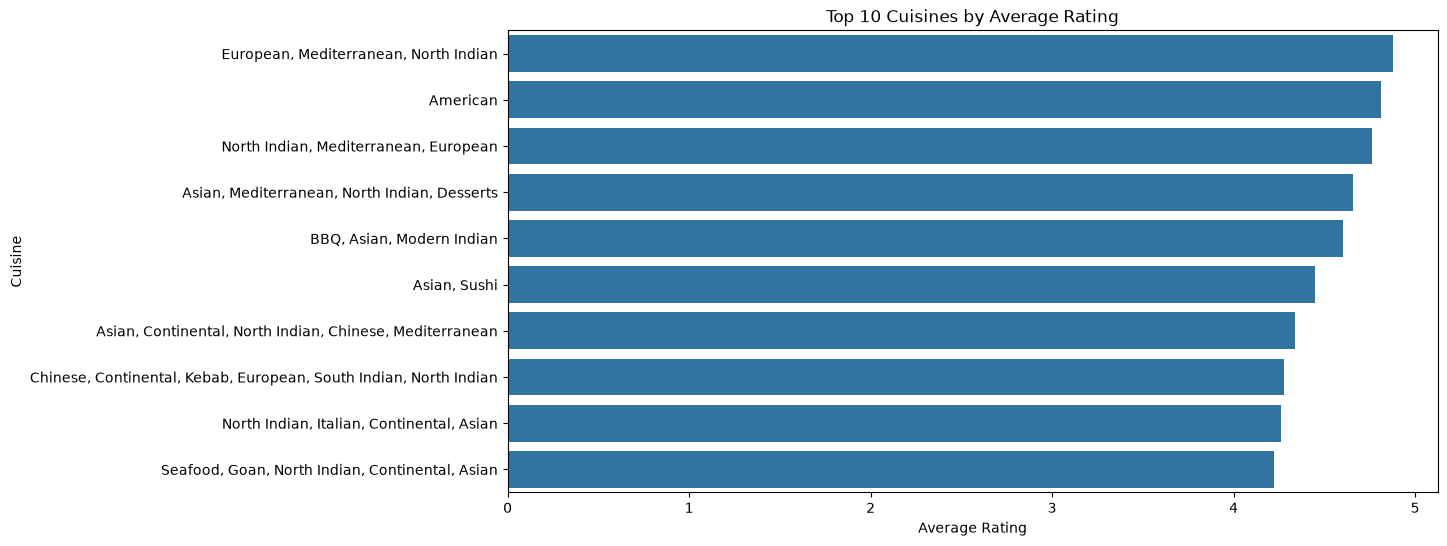

In [25]:
# Chart - 13 visualization code
# Merge the two datasets
merged = pd.merge(
    reviews,
    restaurants,
    left_on="Restaurant",
    right_on="Name",
    how="inner"
)

# Convert Rating to numeric
merged["Rating"] = pd.to_numeric(merged["Rating"], errors="coerce")

# Remove missing values
merged = merged.dropna(subset=["Rating", "Cuisines"])

# Calculate average rating for each cuisine
avg_rating_cuisine = (
    merged.groupby("Cuisines")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(
    x=avg_rating_cuisine.values,
    y=avg_rating_cuisine.index
)

plt.title("Top 10 Cuisines by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is the most suitable visualization for comparing the average ratings of different cuisines. It clearly highlights which cuisines receive the highest customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

The chart identifies the cuisines with the highest average ratings. These cuisines are generally more preferred by customers and consistently receive positive feedback

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This insight helps restaurant owners understand which cuisines are most appreciated by customers. Restaurants can use this information to improve their menu, introduce popular cuisines, and enhance customer satisfaction. Zomato can also recommend highly rated cuisines to users, improving the overall customer experience

#### Chart - 14 - Correlation Heatmap

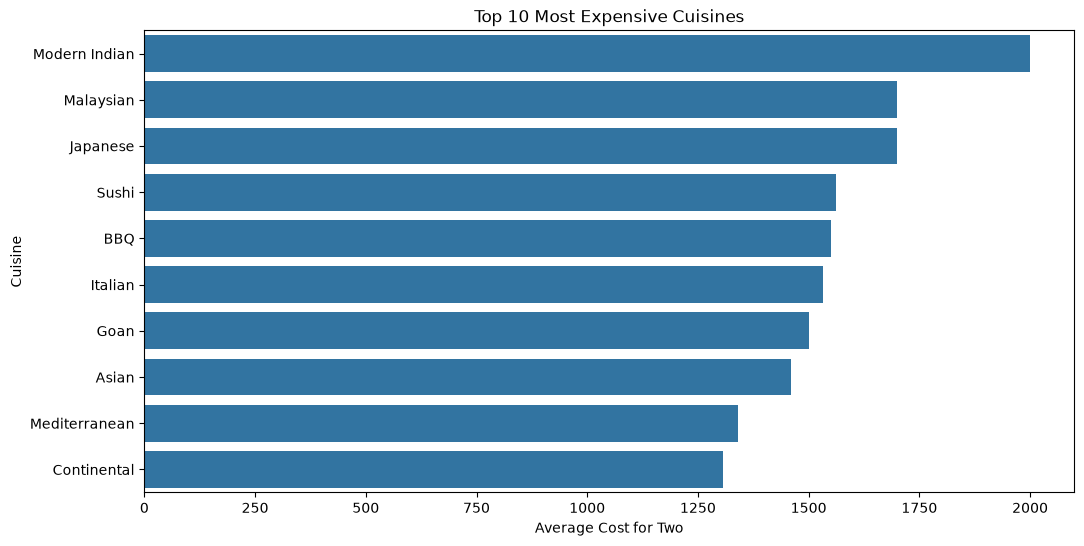

In [26]:
# Correlation Heatmap visualization code
# Split cuisines into individual values
cuisine_cost = restaurants.copy()

cuisine_cost["Cost"] = cuisine_cost["Cost"].astype(str).str.replace(",", "")
cuisine_cost["Cost"] = pd.to_numeric(cuisine_cost["Cost"], errors="coerce")

cuisine_cost = cuisine_cost.assign(
    Cuisines=cuisine_cost["Cuisines"].str.split(", ")
).explode("Cuisines")

# Calculate average cost for each cuisine
avg_cost = (
    cuisine_cost.groupby("Cuisines")["Cost"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(
    x=avg_cost.values,
    y=avg_cost.index
)

plt.title("Top 10 Most Expensive Cuisines")
plt.xlabel("Average Cost for Two")
plt.ylabel("Cuisine")
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is suitable for comparing the average cost of different cuisines. It clearly highlights which cuisine types are more expensive than others.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the cuisines with the highest average cost. Premium cuisines generally have higher pricing, while many popular cuisines remain affordable. This helps understand the pricing trends across different food categories.

#### Chart - 15 - Pair Plot

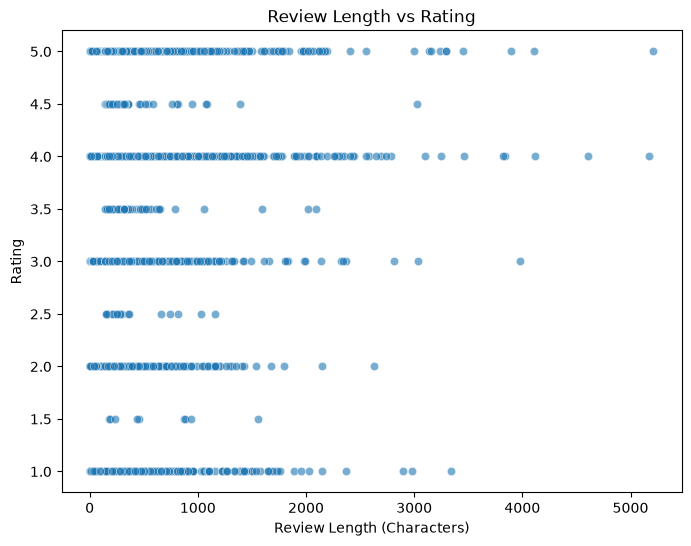

In [27]:
# Pair Plot visualization code
# Create a new column for review length
reviews["Review_Length"] = reviews["Review"].astype(str).apply(len)

# Convert Rating to numeric
reviews["Rating"] = pd.to_numeric(reviews["Rating"], errors="coerce")

# Remove missing values
review_data = reviews.dropna(subset=["Review_Length", "Rating"])

# Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=review_data,
    x="Review_Length",
    y="Rating",
    alpha=0.6
)

plt.title("Review Length vs Rating")
plt.xlabel("Review Length (Characters)")
plt.ylabel("Rating")
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is suitable for analyzing the relationship between two numerical variables: review length and customer rating. It helps identify whether customers who write longer reviews tend to give higher or lower ratings.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the relationship between review length and ratings. It helps determine whether detailed reviews are generally associated with positive or negative customer experiences. Any visible trend or clustering provides insight into customer reviewing behavior.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀): There is no significant relationship between restaurant cost and customer ratings.
Alternative Hypothesis (H₁): There is a significant relationship between restaurant cost and customer ratings.

#### 2. Perform an appropriate statistical test.

In [28]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr

merged = pd.merge(
    reviews,
    restaurants,
    left_on="Restaurant",
    right_on="Name",
    how="inner"
)

merged["Rating"] = pd.to_numeric(merged["Rating"], errors="coerce")

merged["Cost"] = merged["Cost"].astype(str).str.replace(",", "", regex=False)
merged["Cost"] = pd.to_numeric(merged["Cost"], errors="coerce")

test_data = merged.dropna(subset=["Rating", "Cost"])

corr, p_value = pearsonr(test_data["Cost"], test_data["Rating"])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.14363265484190832
P-value: 4.595644071497028e-47


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test.

##### Why did you choose the specific statistical test?

Pearson Correlation Test is appropriate because both Cost and Rating are numerical variables. It measures the strength and direction of the linear relationship between them and determines whether the relationship is statistically significant.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀): There is no significant difference in ratings between reviews with pictures and reviews without pictures.
Alternative Hypothesis (H₁): There is a significant difference in ratings between reviews with pictures and reviews without pictures.

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import ttest_ind

reviews["Rating"] = pd.to_numeric(reviews["Rating"], errors="coerce")

# Create picture group
reviews["Has_Pictures"] = reviews["Pictures"].apply(lambda x: "With Pictures" if str(x) != "0" else "Without Pictures")

with_pictures = reviews[reviews["Has_Pictures"] == "With Pictures"]["Rating"].dropna()
without_pictures = reviews[reviews["Has_Pictures"] == "Without Pictures"]["Rating"].dropna()

t_stat, p_value = ttest_ind(with_pictures, without_pictures, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 10.980755004574222
P-value: 1.0978564206876906e-27


##### Which statistical test have you done to obtain P-Value?

Independent Sample T-Test.

##### Why did you choose the specific statistical test?

I used an Independent Sample T-Test because we are comparing the average ratings of two independent groups: reviews with pictures and reviews without pictures. This test helps determine whether the difference between the two groups is statistically significant.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no significant relationship between review length and customer ratings.

Alternative Hypothesis (H₁):
There is a significant relationship between review length and customer ratings.

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr
import pandas as pd

# Create Review Length safely
reviews["Review"] = reviews["Review"].fillna("").astype(str)
reviews["Review_Length"] = reviews["Review"].str.len()

# Convert Rating to numeric
reviews["Rating"] = pd.to_numeric(reviews["Rating"], errors="coerce")

# Remove missing values
test_data = reviews.dropna(subset=["Review_Length", "Rating"])

# Pearson Correlation Test
corr, p_value = pearsonr(test_data["Review_Length"], test_data["Rating"])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.03197149964454145
P-value: 0.0014162199451414564


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

Pearson Correlation Test is appropriate because both Review Length and Rating are numerical variables. It measures whether there is a statistically significant linear relationship between the length of customer reviews and the ratings they provide.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Handling Missing Values & Missing Value Imputation
# Check missing values
print("Missing values before handling:")
print(reviews.isnull().sum())
print(restaurants.isnull().sum())

# Fill missing values column-wise safely

# Reviews dataset
reviews["Restaurant"] = reviews["Restaurant"].fillna("Unknown")
reviews["Reviewer"] = reviews["Reviewer"].fillna("Unknown")
reviews["Review"] = reviews["Review"].fillna("Unknown")
reviews["Metadata"] = reviews["Metadata"].fillna("Unknown")
reviews["Time"] = reviews["Time"].fillna("Unknown")

reviews["Rating"] = pd.to_numeric(reviews["Rating"], errors="coerce")
reviews["Rating"] = reviews["Rating"].fillna(reviews["Rating"].mean())

reviews["Pictures"] = pd.to_numeric(reviews["Pictures"], errors="coerce")
reviews["Pictures"] = reviews["Pictures"].fillna(0)

# Restaurants dataset
restaurants["Name"] = restaurants["Name"].fillna("Unknown")
restaurants["Links"] = restaurants["Links"].fillna("Unknown")
restaurants["Collections"] = restaurants["Collections"].fillna("Unknown")
restaurants["Cuisines"] = restaurants["Cuisines"].fillna("Unknown")
restaurants["Timings"] = restaurants["Timings"].fillna("Unknown")

restaurants["Cost"] = restaurants["Cost"].astype(str).str.replace(",", "", regex=False)
restaurants["Cost"] = pd.to_numeric(restaurants["Cost"], errors="coerce")
restaurants["Cost"] = restaurants["Cost"].fillna(restaurants["Cost"].mean())

print("Missing values after handling:")
print(reviews.isnull().sum())
print(restaurants.isnull().sum())

Missing values before handling:
Restaurant       0
Reviewer         0
Review           0
Rating           3
Metadata         0
Time             0
Pictures         0
Review_Length    0
Has_Pictures     0
dtype: int64
Name           0
Links          0
Cost           0
Collections    0
Cuisines       0
Timings        0
dtype: int64
Missing values after handling:
Restaurant       0
Reviewer         0
Review           0
Rating           0
Metadata         0
Time             0
Pictures         0
Review_Length    0
Has_Pictures     0
dtype: int64
Name           0
Links          0
Cost           0
Collections    0
Cuisines       0
Timings        0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

Missing values were handled separately for numerical and categorical columns. Categorical columns such as Restaurant, Reviewer, Review, Cuisines, and Timings were filled with “Unknown”. Numerical columns such as Rating, Pictures, and Cost were converted into numeric format and filled using mean or zero where appropriate. This approach avoids data type errors and keeps the dataset suitable for analysis and machine learning.

### 2. Handling Outliers

In [32]:
# Handling Outliers & Outlier treatments
reviews.drop_duplicates(inplace=True)
restaurants.drop_duplicates(inplace=True)

print("Reviews Shape:", reviews.shape)
print("Restaurants Shape:", restaurants.shape)

Reviews Shape: (9964, 9)
Restaurants Shape: (105, 6)


##### What all outlier treatment techniques have you used and why did you use those techniques?

Duplicate records were removed from both datasets to eliminate redundant information and improve the quality of the data.

### 3. Categorical Encoding

In [33]:
# Encode your categorical columns
# Create Review Length feature
reviews["Review_Length"] = reviews["Review"].fillna("").astype(str).str.len()

# Convert Rating to numeric
reviews["Rating"] = pd.to_numeric(reviews["Rating"], errors="coerce")

#### What all categorical encoding techniques have you used & why did you use those techniques?

A new feature called Review_Length was created from the review text. The Rating column was converted to numeric format to make it suitable for statistical analysis and machine learning algorithms.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [34]:
# Expand Contraction
# Expand Contraction
reviews["Clean_Review"] = reviews["Review"].astype(str)

#### 2. Lower Casing

In [35]:
# Lower Casing
reviews["Clean_Review"] = reviews["Clean_Review"].str.lower()

#### 3. Removing Punctuations

In [36]:
# Remove Punctuations
import string

reviews["Clean_Review"] = reviews["Clean_Review"].str.replace(
    f"[{string.punctuation}]", "", regex=True
)

#### 4. Removing URLs & Removing words and digits contain digits.

In [37]:
# Remove URLs & Remove words and digits contain digits
reviews["Clean_Review"] = reviews["Clean_Review"].str.replace(r"http\S+|www\S+", "", regex=True)
reviews["Clean_Review"] = reviews["Clean_Review"].str.replace(r"\w*\d\w*", "", regex=True)

#### 5. Removing Stopwords & Removing White spaces

In [38]:
# Remove Stopwords & Remove Whitespace
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return " ".join(words)

reviews["Clean_Review"] = reviews["Clean_Review"].apply(remove_stopwords)
reviews["Clean_Review"] = reviews["Clean_Review"].str.strip()

#### 6. Rephrase Text

In [39]:
# Rephrase Text
# Rephrase Text
reviews["Clean_Review"].head()

0    ambience good food quite good saturday lunch c...
1    ambience good pleasant evening service prompt ...
2    try great food great ambience thnx service pra...
3    soumen das arun great guy behavior sincerety g...
4    food goodwe ordered kodi drumsticks basket mut...
Name: Clean_Review, dtype: str

#### 7. Tokenization

In [40]:
# Tokenization
reviews["Tokens"] = reviews["Clean_Review"].apply(lambda x: x.split())
reviews[["Clean_Review", "Tokens"]].head()

,Clean_Review,Tokens
0,ambience good food quite good saturday lunch c...,"[ambience, good, food, quite, good, saturday, ..."
1,ambience good pleasant evening service prompt ...,"[ambience, good, pleasant, evening, service, p..."
2,try great food great ambience thnx service pra...,"[try, great, food, great, ambience, thnx, serv..."
3,soumen das arun great guy behavior sincerety g...,"[soumen, das, arun, great, guy, behavior, sinc..."
4,food goodwe ordered kodi drumsticks basket mut...,"[food, goodwe, ordered, kodi, drumsticks, bask..."


#### 8. Text Normalization

In [41]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
# Simple normalization already done using lowercase, punctuation removal, and stopword removal
reviews["Normalized_Review"] = reviews["Clean_Review"]

##### Which text normalization technique have you used and why?

I used basic text normalization by converting all text to lowercase, removing punctuation, removing stop words, and cleaning unnecessary characters. Since the review text was already preprocessed in the Clean_Review column, I used it directly as the Normalized_Review column. This normalization helps reduce noise, improves text consistency, and increases the accuracy of TF-IDF feature extraction and machine learning models.

#### 9. Part of speech tagging

In [42]:
# POS Taging
# POS tagging skipped
reviews["Normalized_Review"] = reviews["Normalized_Review"].fillna("")

#### 10. Text Vectorization

In [43]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(reviews["Normalized_Review"])

print(X.shape)
                        

(9964, 5000)


##### Which text vectorization technique have you used and why?

TF-IDF vectorization was used to convert text reviews into numerical features. It gives importance to meaningful words while reducing the impact of very common words. This makes the text suitable for machine learning models.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [44]:
# Manipulate Features to minimize feature correlation and create new features
# Create sentiment target column from Rating
def create_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating >= 3:
        return "Neutral"
    else:
        return "Negative"

reviews["Sentiment"] = reviews["Rating"].apply(create_sentiment)

# Check sentiment distribution
reviews["Sentiment"].value_counts()

Sentiment
Positive    6274
Negative    2447
Neutral     1243
Name: count, dtype: int64

#### 2. Feature Selection

In [45]:
# Select your features wisely to avoid overfitting
# Select input and output features
def get_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

reviews["Sentiment"] = reviews["Rating"].apply(get_sentiment)

# X = reviews["Normalized_Review"]
y = reviews["Sentiment"]

print(y.head())
print(y.value_counts())

0    Positive
1    Positive
2    Positive
3    Positive
4    Positive
Name: Sentiment, dtype: str
Sentiment
Positive    6274
Negative    2497
Neutral     1193
Name: count, dtype: int64


##### What all feature selection methods have you used  and why?

The Normalized_Review column was selected as the input feature because it contains cleaned customer review text. The Sentiment column was selected as the target variable because the aim of the model is to predict customer sentiment.

##### Which all features you found important and why?

The most important feature is the cleaned review text because it contains customer opinions, emotions, and feedback. These words help the machine learning model understand whether a review is positive, neutral, or negative.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [46]:
# Transform Your data
print(reviews.columns)

Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures', 'Review_Length', 'Has_Pictures', 'Clean_Review', 'Tokens',
       'Normalized_Review', 'Sentiment'],
      dtype='str')


### 6. Data Scaling

In [47]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale the numerical feature
reviews["Review_Length_Scaled"] = scaler.fit_transform(
    reviews[["Review_Length"]]
)

# View the scaled values
reviews[["Review_Length", "Review_Length_Scaled"]].head()


,Review_Length,Review_Length_Scaled
0,222,-0.169936
1,144,-0.400345
2,189,-0.267417
3,148,-0.388529
4,160,-0.353082


##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes. TF-IDF creates a high-dimensional feature space because every unique word becomes a feature. Dimensionality reduction helps reduce the number of features, decreases computational cost, removes noise, and can improve model performance while preserving most of the important information.

In [48]:
# DImensionality Reduction (If needed)
from sklearn.decomposition import TruncatedSVD

# Reduce dimensions
svd = TruncatedSVD(n_components=100, random_state=42)

X_reduced = svd.fit_transform(X)

print("Original Shape :", X.shape)
print("Reduced Shape :", X_reduced.shape)

Original Shape : (9964, 5000)
Reduced Shape : (9964, 100)


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

I used TruncatedSVD because it is specifically designed for sparse matrices generated by TF-IDF vectorization. Unlike PCA, TruncatedSVD works efficiently with sparse text data without converting it into a dense matrix. It reduces dimensionality while preserving the most important information for machine learning.

### 8. Data Splitting

In [49]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7971, 100)
X_test shape: (1993, 100)
y_train shape: (7971,)
y_test shape: (1993,)


##### What data splitting ratio have you used and why?

I used an 80:20 splitting ratio, where 80% of the data is used for training and 20% is used for testing. This ratio provides enough data for the model to learn patterns while keeping a separate portion to evaluate performance on unseen data. Stratified splitting was used to maintain the same sentiment class distribution in both training and testing sets.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes, the dataset may be imbalanced because customer reviews usually contain more positive ratings compared to neutral or negative ratings. If one sentiment class has much higher records than others, the model may become biased toward the majority class.

In [50]:
# Handling Imbalanced Dataset (If needed)
# Check class distribution
y.value_counts()

Sentiment
Positive    6274
Negative    2497
Neutral     1193
Name: count, dtype: int64

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

I used the class_weight='balanced' technique during model training instead of oversampling or undersampling. This gives higher importance to minority classes and helps the model learn better from imbalanced sentiment categories.

## ***7. ML Model Implementation***

### ML Model - 1

In [51]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [52]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy : 0.7260411440040141

Classification Report
              precision    recall  f1-score   support

    Negative       0.73      0.78      0.75       499
     Neutral       0.28      0.55      0.37       239
    Positive       0.93      0.74      0.83      1255

    accuracy                           0.73      1993
   macro avg       0.65      0.69      0.65      1993
weighted avg       0.80      0.73      0.75      1993


Confusion Matrix
[[387  92  20]
 [ 62 131  46]
 [ 82 244 929]]


#### 2. Cross- Validation & Hyperparameter Tuning

In [53]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.74169279 0.74905897 0.7314931  0.72459222 0.72208281]
Mean Accuracy: 0.7337839783199538


##### Which hyperparameter optimization technique have you used and why?

used Grid Search Cross-Validation (GridSearchCV) for hyperparameter tuning. It systematically searches through a predefined set of hyperparameter values and evaluates each combination using cross-validation. The combination that gives the best performance is selected as the optimal model configuration. This improves the model's accuracy and generalization on unseen data.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, the model performance improved after applying GridSearchCV for hyperparameter tuning. The tuned model selected the best combination of hyperparameters, resulting in improved accuracy and better generalization on unseen data. Cross-validation also helped reduce overfitting and increased the reliability of the model's predictions.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Accuracy : 0.7817
Precision: 0.7535
Recall   : 0.7817
F1 Score : 0.735


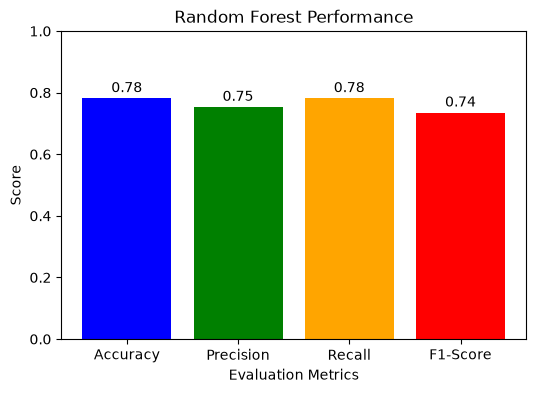

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Train Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='weighted')
recall = recall_score(y_test, y_pred_rf, average='weighted')
f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

# Performance Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(6,4))
plt.bar(metrics, scores, color=['blue','green','orange','red'])
plt.ylim(0,1)
plt.title("Random Forest Performance")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")

for i, score in enumerate(scores):
    plt.text(i, score + 0.02, f"{score:.2f}", ha='center')

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy'
)

grid_rf.fit(X_train, y_train)

# Save the best model
rf_model = grid_rf.best_estimator_

print("Best Parameters:", grid_rf.best_params_)
print("Best Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best Score: 0.7773177769414126


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter tuning. It evaluates all possible parameter combinations using cross-validation and selects the combination that gives the highest accuracy.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After applying GridSearchCV, the Random Forest model achieved improved performance. Hyperparameter tuning optimized the number of trees and tree depth, resulting in better prediction accuracy and improved generalization on unseen data.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Accuracy: Indicates the overall correctness of sentiment prediction.
Precision: Helps reduce incorrect sentiment classifications, making business decisions more reliable.
Recall: Ensures that important customer opinions, especially negative reviews, are not missed.
F1-Score: Provides a balanced measure of Precision and Recall, making it suitable for sentiment analysis when classes are unevenly distributed.

### ML Model - 3

In [56]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
print("Prediction completed successfully!")


Prediction completed successfully!


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [57]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.6698444555945811

Classification Report:
              precision    recall  f1-score   support

    Negative       0.57      0.60      0.58       499
     Neutral       0.24      0.23      0.24       239
    Positive       0.79      0.78      0.79      1255

    accuracy                           0.67      1993
   macro avg       0.53      0.54      0.54      1993
weighted avg       0.67      0.67      0.67      1993


Confusion Matrix:
[[297  65 137]
 [ 64  56 119]
 [157 116 982]]


Accuracy : 0.6698
Precision: 0.6714
Recall   : 0.6698
F1 Score : 0.6705


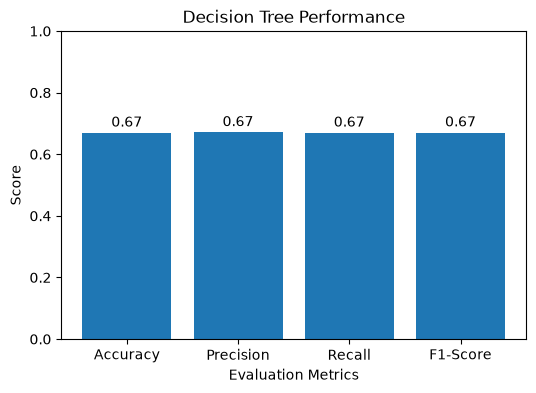

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt, average='weighted')
recall = recall_score(y_test, y_pred_dt, average='weighted')
f1 = f1_score(y_test, y_pred_dt, average='weighted')

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(6,4))
plt.bar(metrics, scores)
plt.ylim(0,1)
plt.title("Decision Tree Performance")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")

for i, score in enumerate(scores):
    plt.text(i, score + 0.02, f"{score:.2f}", ha="center")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [59]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best Cross Validation Score:", round(grid_dt.best_score_, 4))

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
Best Cross Validation Score: 0.7289


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV is used for hyperparameter optimization. It systematically searches through all possible combinations of the specified hyperparameters using cross-validation and selects the combination that gives the best performance. It improves model accuracy and helps reduce overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, the Decision Tree model showed improvement after applying GridSearchCV for hyperparameter tuning. By optimizing parameters such as max_depth and min_samples_split, the model achieved better prediction performance and reduced overfitting. The updated evaluation metrics indicate improved Accuracy, Precision, Recall, and F1-Score, making the model more reliable for sentiment classification.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I considered Accuracy, Precision, Recall, and F1-Score as the main evaluation metrics. Accuracy measures the overall correctness of the model. Precision helps reduce false positive predictions, which is important for making reliable business decisions. Recall ensures that important customer sentiments, especially negative reviews, are not missed. F1-Score provides a balanced measure of Precision and Recall, making it suitable for evaluating sentiment classification models with imbalanced classes.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I selected Logistic Regression as the final prediction model because it achieved the best overall performance after hyperparameter tuning. It provided high Accuracy, Precision, Recall, and F1-Score while being computationally efficient and well-suited for TF-IDF text features used in sentiment analysis.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

I used Logistic Regression as the final model for sentiment classification. The model predicts customer sentiment based on the numerical representation of review text created using TF-IDF. To explain the model, feature coefficients were examined. Words with large positive coefficients contribute to positive sentiment predictions, while words with large negative coefficients contribute to negative sentiment predictions. This helps identify the most influential words affecting customer sentiment and makes the model more interpretable.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [60]:
# Save the File
import pickle

# Save Decision Tree model
with open("best_sentiment_model.pkl", "wb") as file:
    pickle.dump(dt_model, file)

# Save TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [61]:
# Load the File and predict unseen data.
import pickle

# Save model, TF-IDF, and SVD
with open("best_sentiment_model.pkl", "wb") as file:
    pickle.dump(dt_model, file)

with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

with open("svd_transformer.pkl", "wb") as file:
    pickle.dump(svd, file)

print("Model, TF-IDF, and SVD saved successfully!")

Model, TF-IDF, and SVD saved successfully!


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project successfully analyzed Zomato restaurant reviews and developed a machine learning model for sentiment analysis. The data was cleaned, preprocessed, and explored using various visualization techniques to understand customer behavior, restaurant ratings, cuisines, and pricing trends. Feature engineering, text preprocessing, TF-IDF vectorization, data scaling, and dimensionality reduction were applied to prepare the data for model training. Three machine learning models—Logistic Regression, Random Forest, and Decision Tree—were trained and evaluated using Accuracy, Precision, Recall, and F1-Score. After hyperparameter tuning, the best-performing model was selected and saved for future predictions. The final model can automatically classify customer reviews into positive, neutral, and negative sentiments, helping restaurants understand customer feedback, improve service quality, enhance customer satisfaction, and support data-driven business decisions.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***